In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
out_dir = '.'
devices = ['cpu', 'gpu_h200', 'gpu_b200', 'gpu_rtx6000']

In [3]:
def collect(runs_by_dim, key):
    """Return (valid_dims, medians, all_values) skipping dims with no data."""
    valid_dims, medians, all_values = [], [], []
    for d in dims:
        if d not in runs_by_dim:
            continue
        vals = [row[key] for row in runs_by_dim[d]]
        valid_dims.append(d)
        medians.append(np.median(vals))
        all_values.append(vals)
    return np.array(valid_dims), medians, all_values

def any_row_has_key(runs_by_method, key):
    return any(
        key in row
        for runs_by_dim in runs_by_method.values()
        for rows in runs_by_dim.values()
        for row in rows
    )

def plot_series(ax, d_arr, medians, all_values, marker, label, color, linestyle='-'):
    if len(d_arr) == 0:
        return
    line, = ax.plot(d_arr, medians, marker=marker, linestyle=linestyle, label=label, color=color)
    for d, vals in zip(d_arr, all_values):
        ax.scatter([d] * len(vals), vals, marker=marker, color=color, alpha=0.25, s=15, zorder=3)

def style_axis(ax, dims, title, ylabel, fontsize):
    ax.set_xlabel('Dimension $d$', fontsize=fontsize)
    ax.set_ylabel(ylabel, fontsize=fontsize)
    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_xticks(dims)
    ax.set_xticklabels(dims, rotation=45, ha='right')
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_title(title, fontsize=fontsize)

def plot_nonbasic(data, dims, basic_runs, jit=False, suptitle="", 
                  figsize=(6*2.5, (3/4)*6*2), fontsize=12):
    runs_by_method = {
        'basic':    basic_runs,
        'dq_basic': data['dq_basic_jit'] if jit else data['dq_basic'],
        'cayley':   data['cayley_jit'] if jit else data['cayley'],
        'sparse':   data['sambe_sparse_jit'] if jit else data['sambe_sparse'],
        'dense':    data['sambe_dense_jit'] if jit else data['sambe_dense'],
    }
    methods = [
        ('basic',    'o', 'blue',   'Basic (QuTiP)'),
        ('dq_basic', 's', 'orange', 'Basic (Dynamiqs)'),
        ('cayley',   '^', 'green',  'Cayley (Dynamiqs)'),
        ('sparse',   'D', 'red',    'Sambe (Dynamiqs, sparse)'),
        ('dense',    'P', 'purple', 'Sambe (Dynamiqs, dense)'),
    ]

    has_gpu_mem = any_row_has_key(runs_by_method, 'mem_gpu')

    fig1, axs1 = plt.subplots(1, 3, figsize=(6*3, (3/4)*6), constrained_layout=True)
    fig2, axs2 = plt.subplots(1, 2, figsize=(6*2.5, (3/4)*6), constrained_layout=True)
    axs = np.concatenate([axs1, axs2])

    panels = [
        (axs[0], 't_total',   methods,    'Time (s)',                              'Wall time vs. dimension', 'log'),
        (axs[1], 'mem_total', methods,    'Memory Host (MB)',                      'Memory Host vs. dimension', 'log'),
    ]
    if has_gpu_mem:
        panels.append((axs[2], 'mem_gpu', methods[1:], 'Memory GPU (MB)', 'Memory GPU vs. dimension', 'log'))
    else:
        panels.append((axs[2], None, None, None, None, None))
    panels.append((axs[3], 'qerr', methods[1:], 'Max quasienergy difference', 'Quasienergy error vs. dimension', 'log'))
    panels.append((axs[4], 'merr', methods[1:], 'Max Floquet mode component difference', 'Floquet mode error vs. dimension', 'log'))

    for ax, key, ms, ylabel, title, yscale in panels:
        if key is None:
            continue
        for mkey, marker, color, label in ms:
            plot_series(ax, *collect(runs_by_method[mkey], key), 
                        marker=marker, color=color, label=label)
        style_axis(ax, dims, title, ylabel, fontsize)
        ax.set_yscale(yscale)

    # Diagonalization-only timings, shown only on the time panel.
    for mkey, marker, color, label in [
        ('dq_basic', 's', 'pink', 'Basic (Dynamiqs, without propagator)'),
        ('cayley',   '^', 'brown', 'Cayley (Dynamiqs, without propagator)'),
    ]:
        plot_series(axs[0], *collect(runs_by_method[mkey], 't_solver'), 
                    marker=marker, color=color, label=label, linestyle='--')

    # All subplots share the same method legend; show it once to the right of the figure.
    handles, labels = [], []
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    fig1.legend(handles, labels, loc='outside right center', fontsize=fontsize)
    fig2.legend(handles, labels, loc='outside right center', fontsize=fontsize)

    if suptitle:
        fig1.suptitle(suptitle, fontsize=1.5*fontsize)
        fig2.suptitle(suptitle, fontsize=1.5*fontsize)
    
    plt.show()

# Load the qutip data

In [4]:
data = np.load(f'{out_dir}/basic.npy', allow_pickle=True).item()
basic_runs    = data['basic']
dims = np.array(sorted(basic_runs.keys()))

In [5]:
#### 
# Optional: remove the stored quasienergies and Floquet modes, to save space

# basic_runs_copy = basic_runs.copy()
# for dim in basic_runs_copy.keys():
#     for run_idx, _ in enumerate(basic_runs_copy[dim]):
#         _ = basic_runs_copy[dim][run_idx].pop('q', None)
#         _ = basic_runs_copy[dim][run_idx].pop('m', None)

# np.save('basic_cp.npy', {'basic' : basic_runs_copy})

# data = np.load(f'{out_dir}/basic_cp.npy', allow_pickle=True).item()
# basic_runs    = data['basic']
# dims = np.array(sorted(basic_runs.keys()))

# Plot all the other data

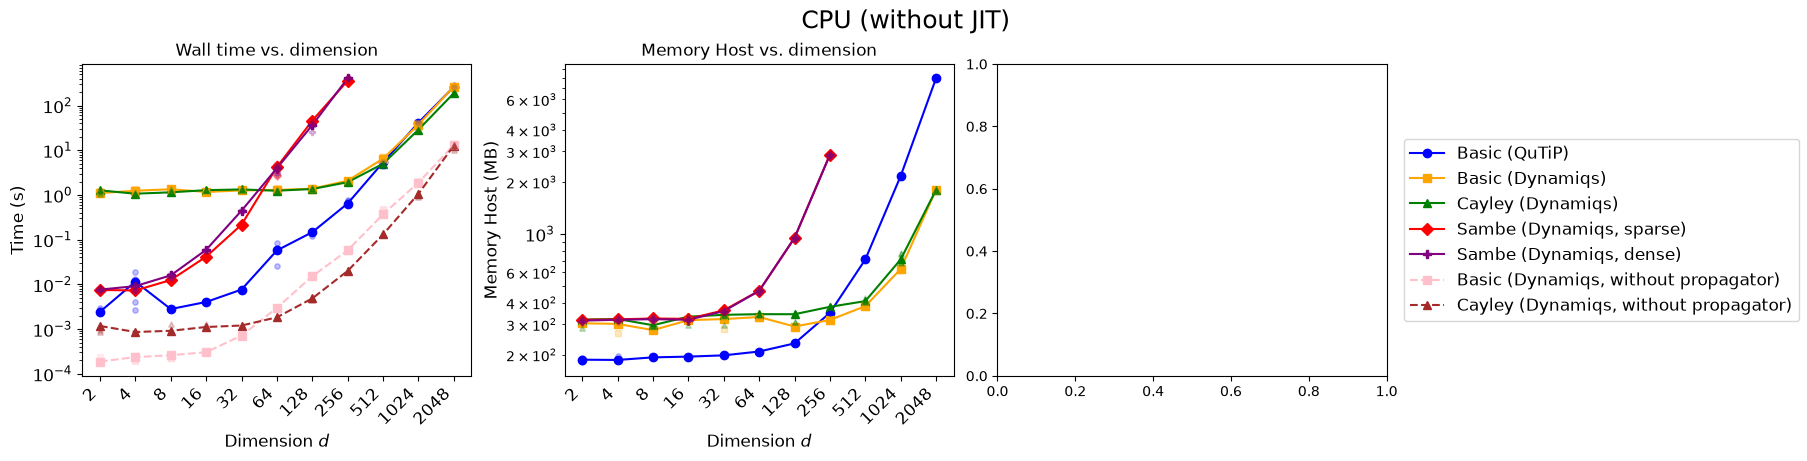

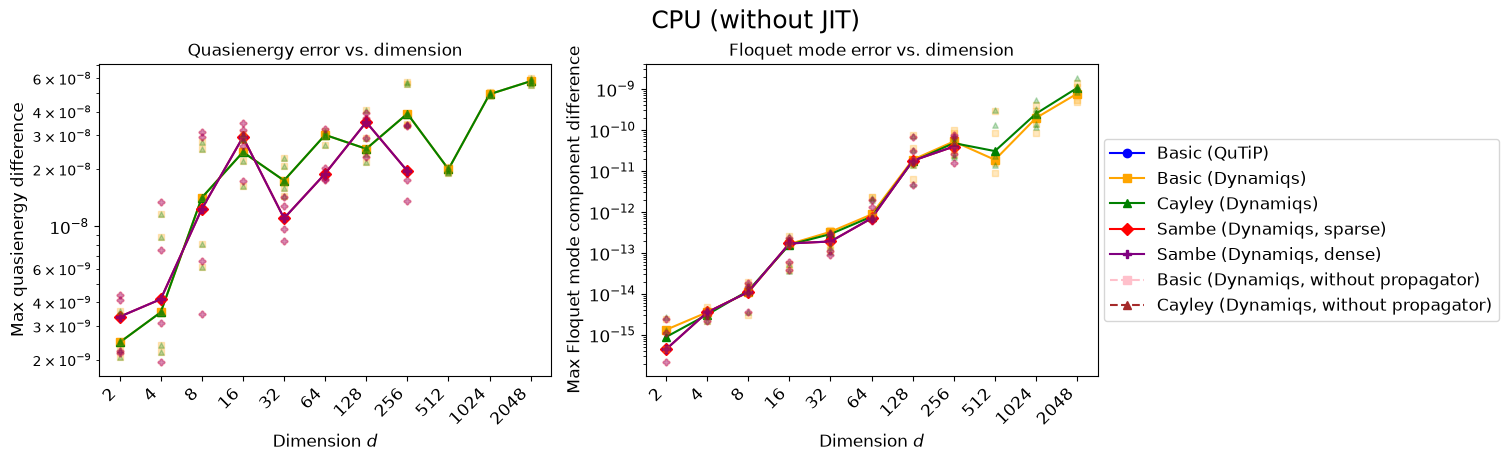

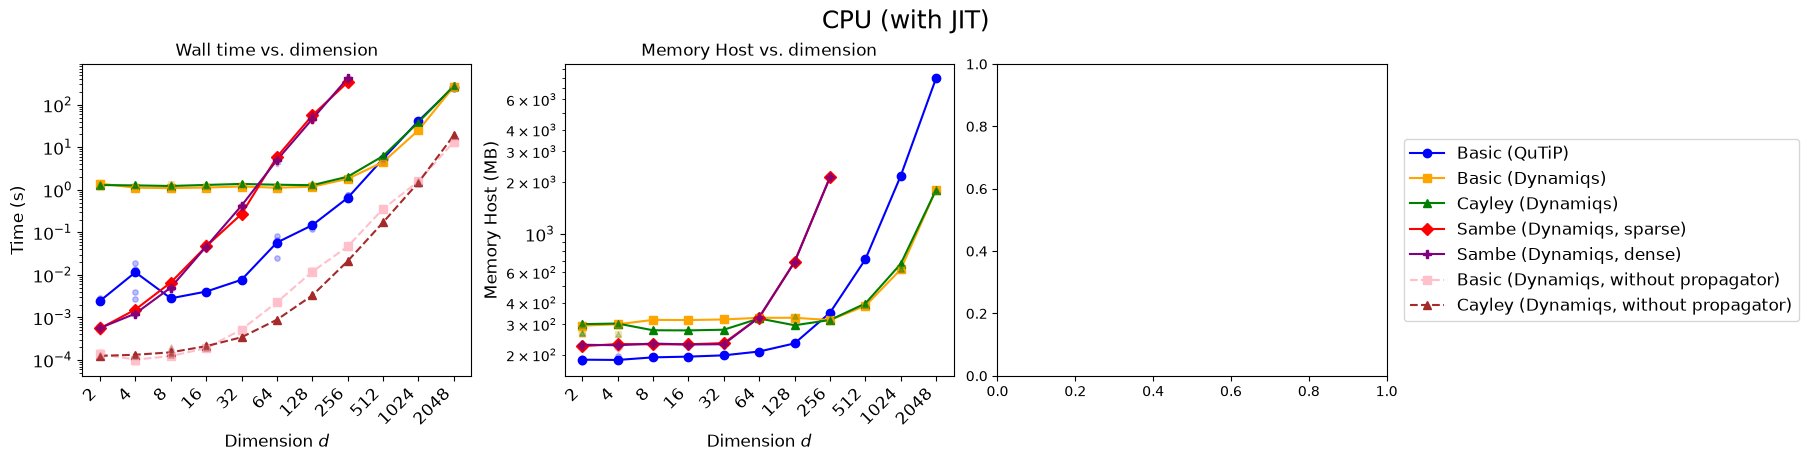

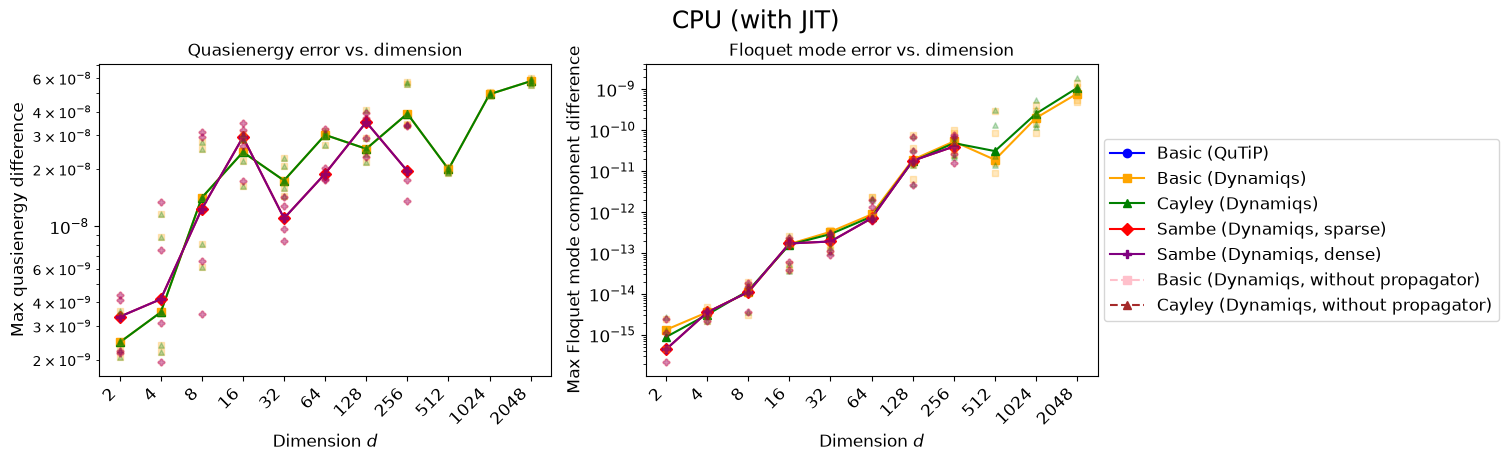

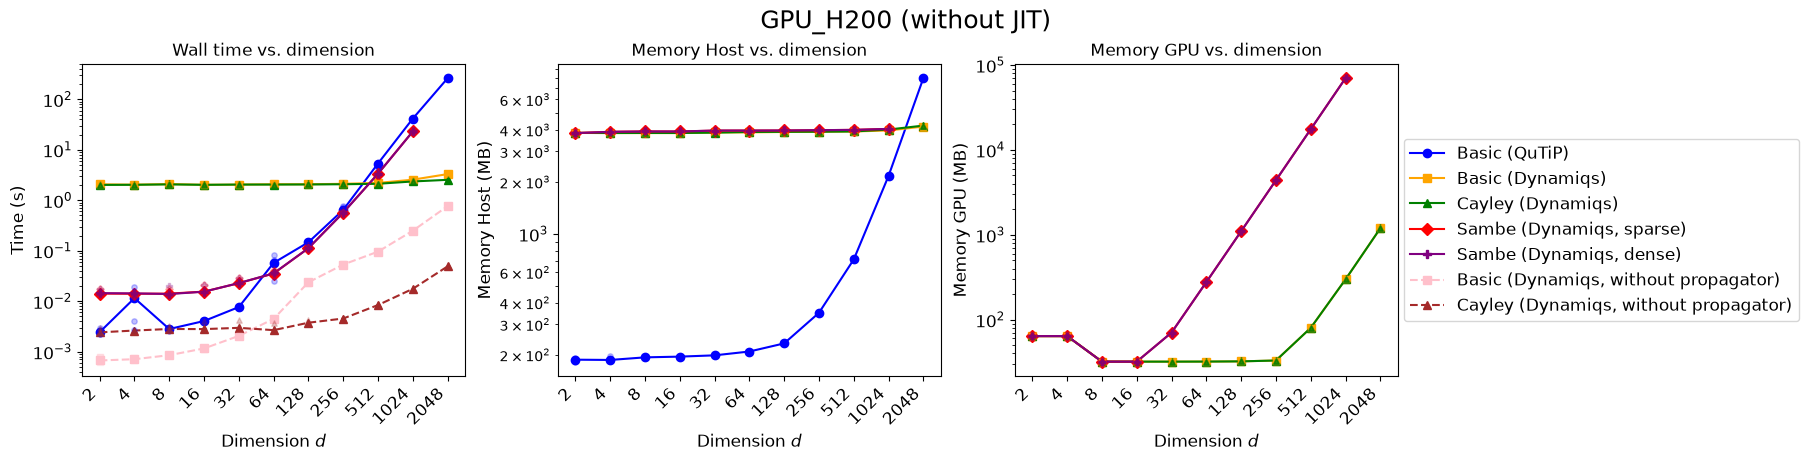

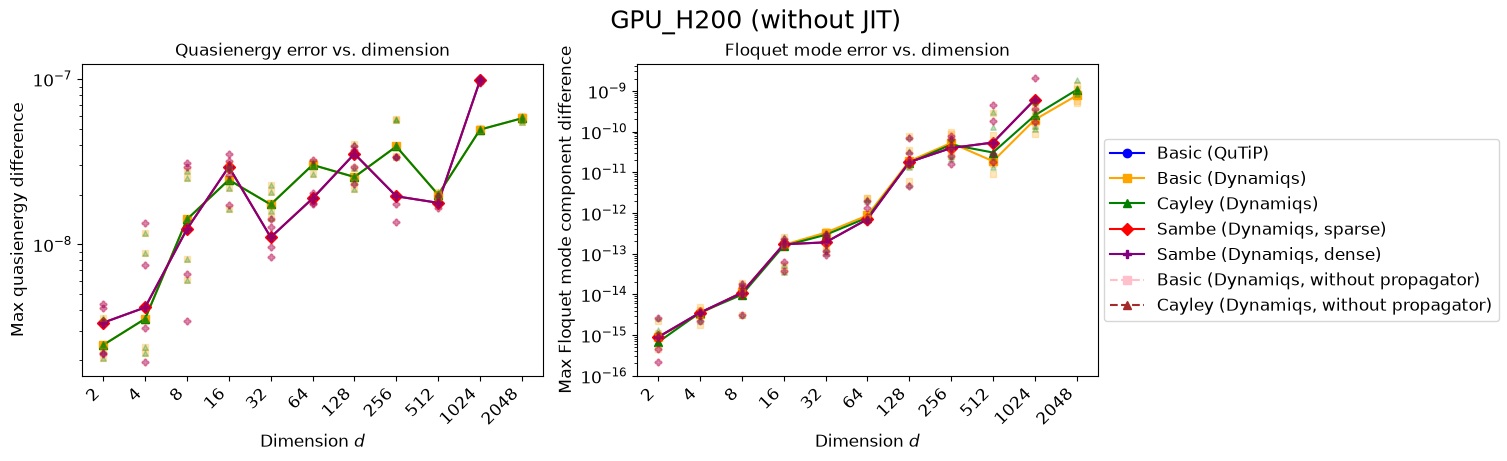

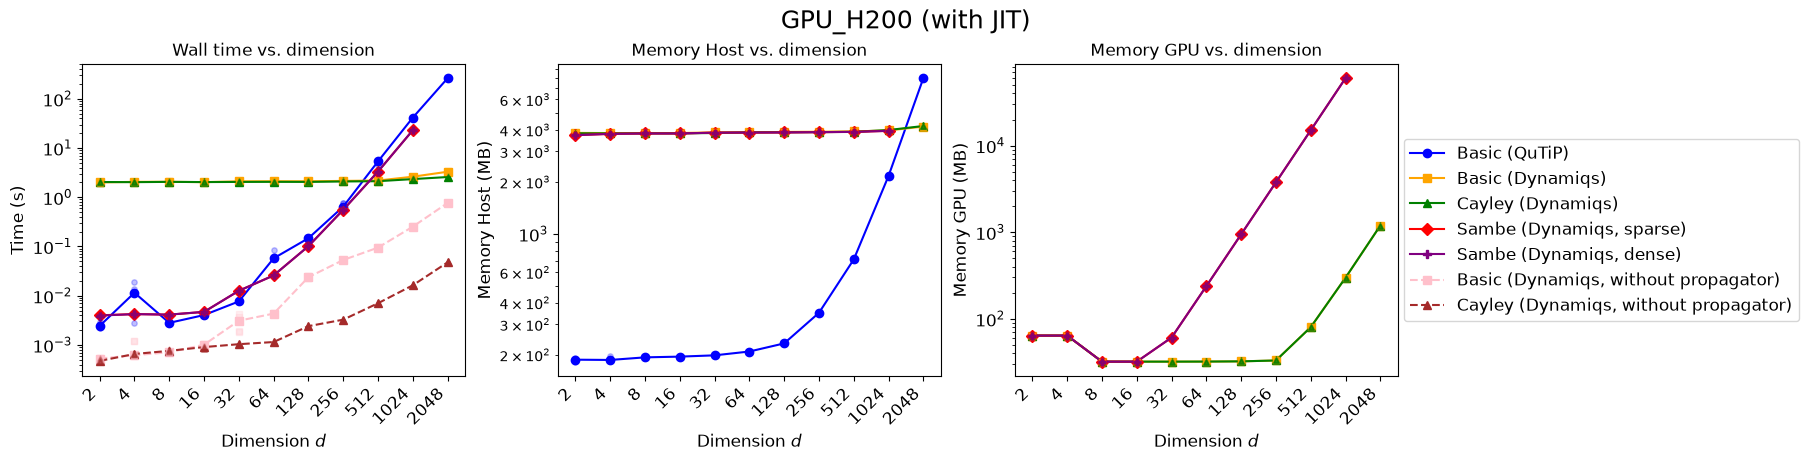

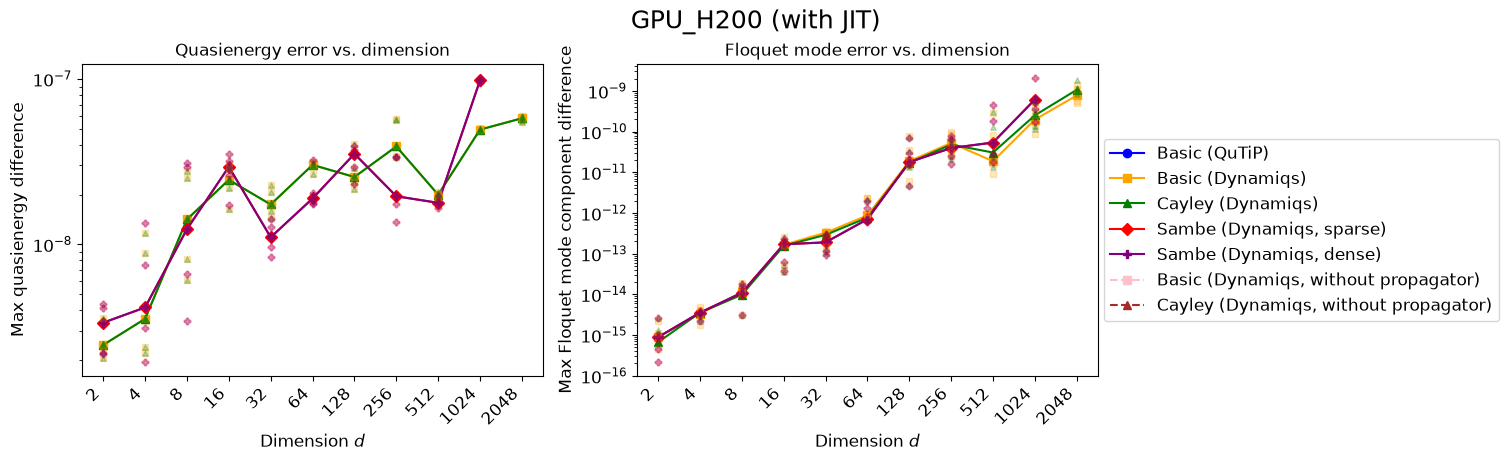

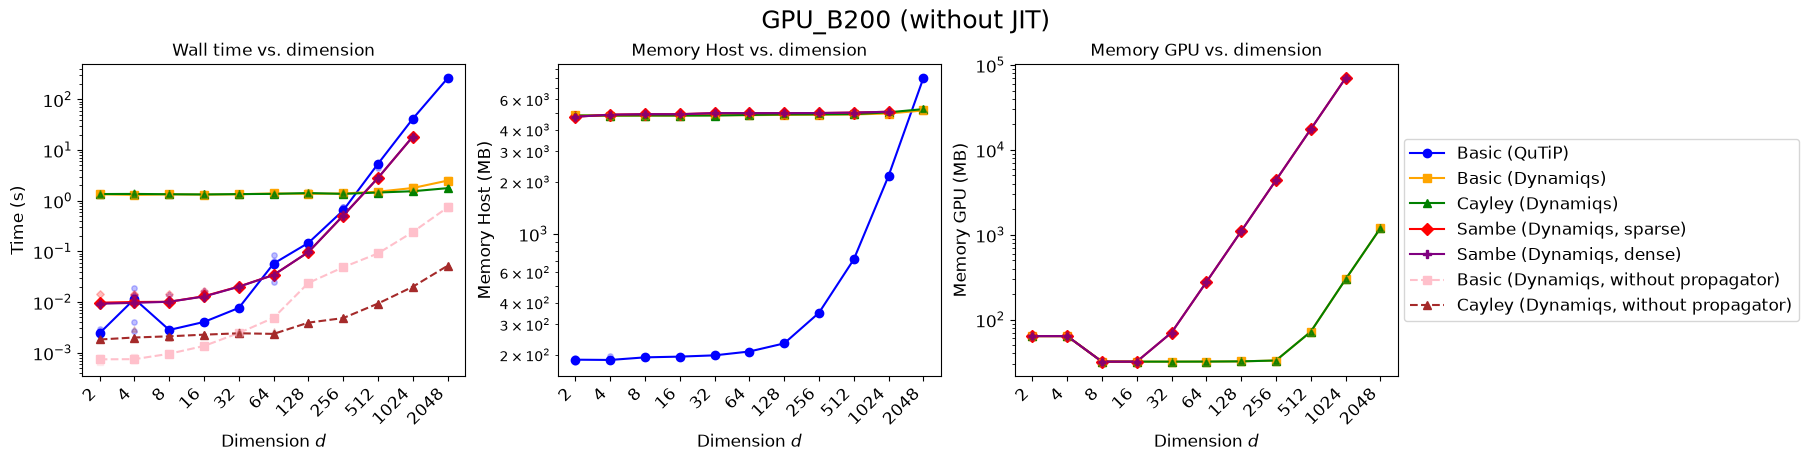

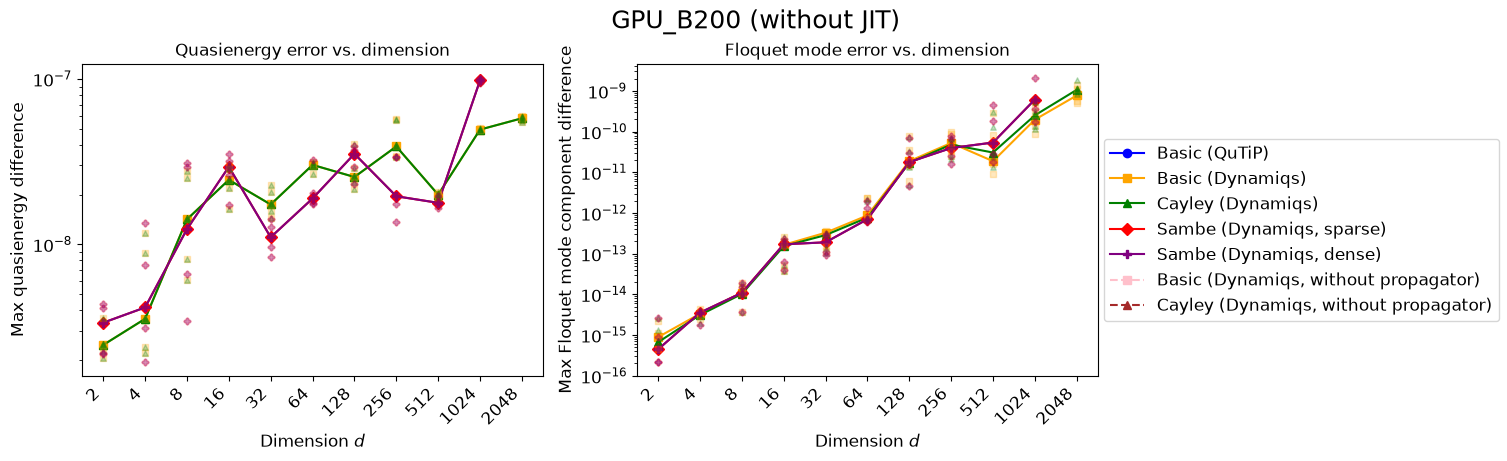

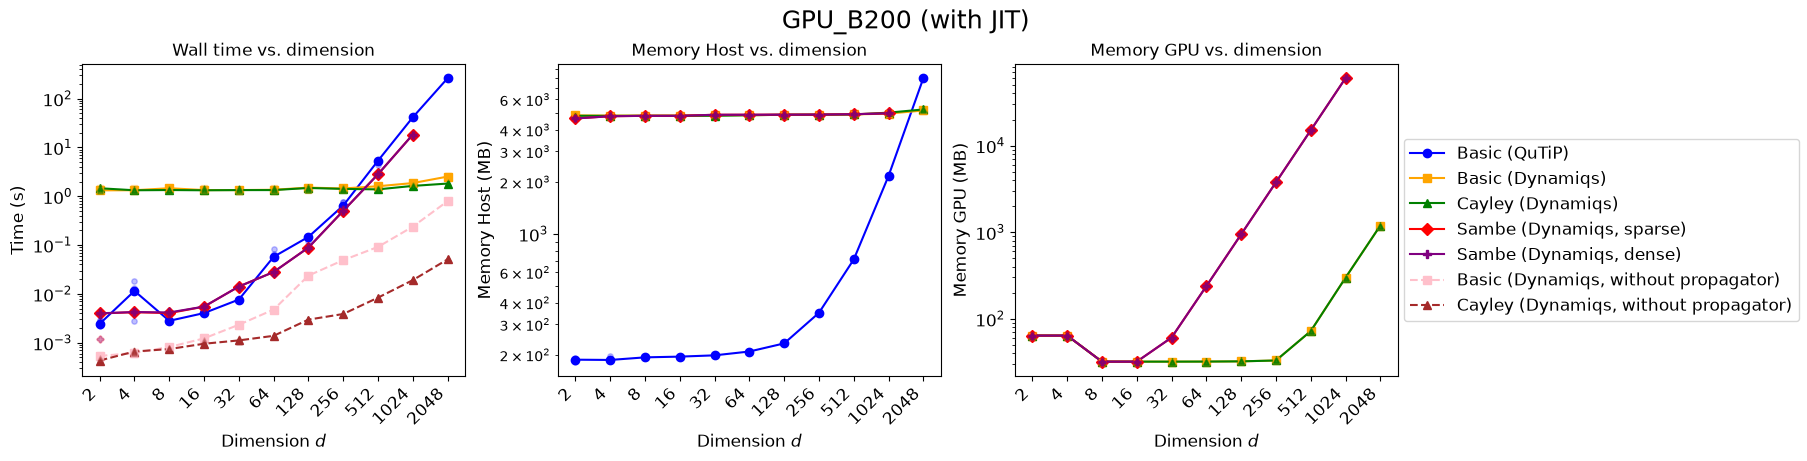

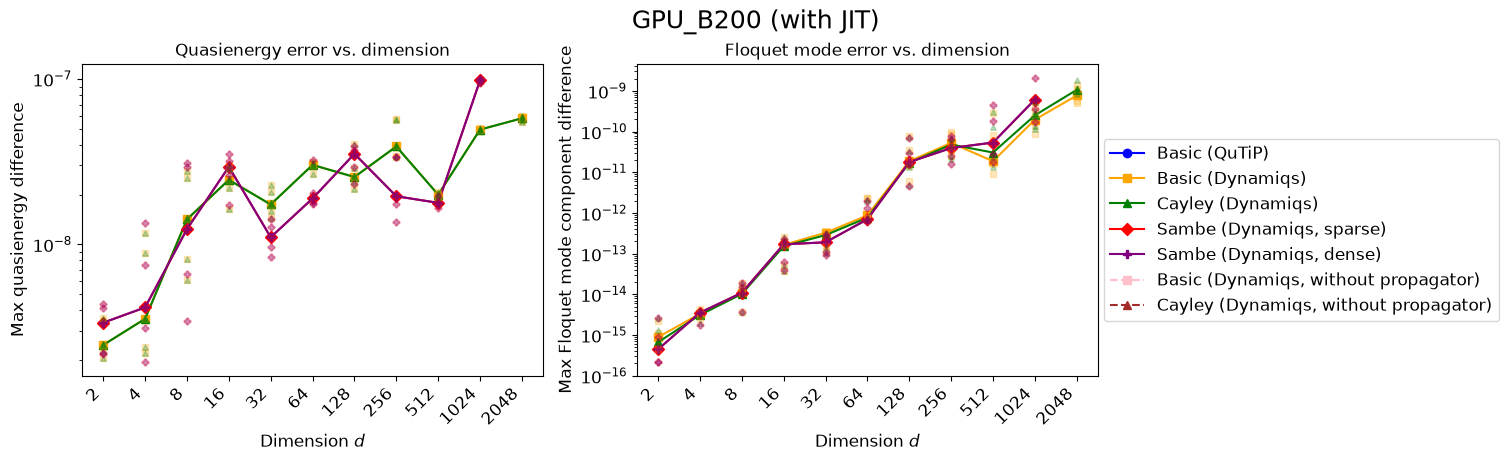

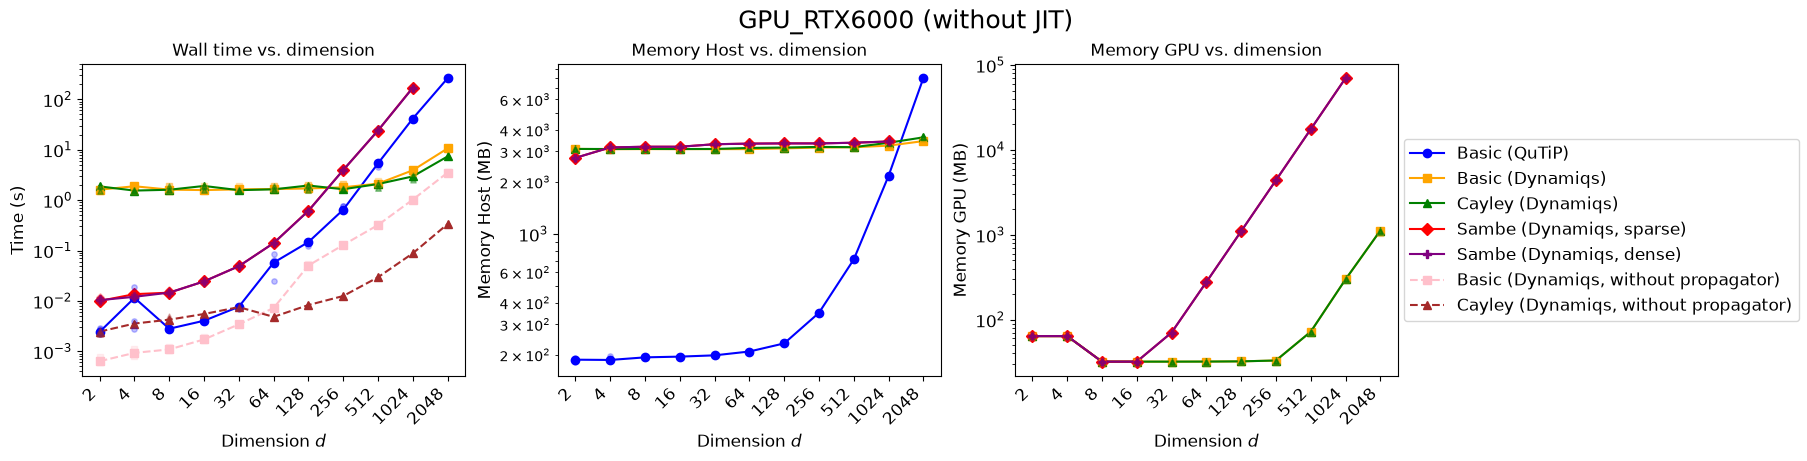

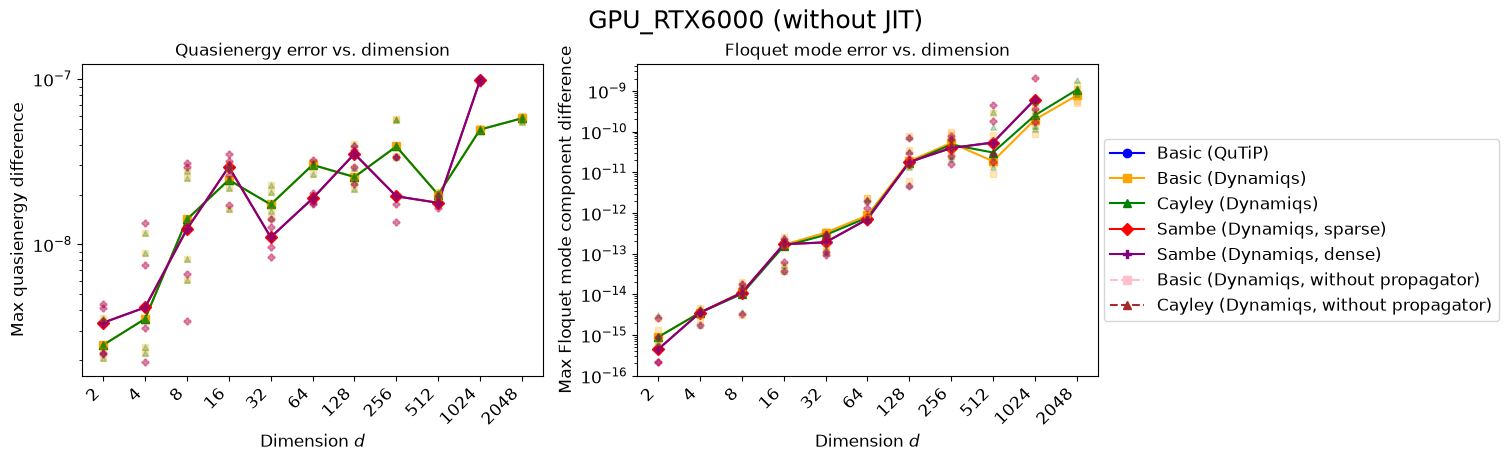

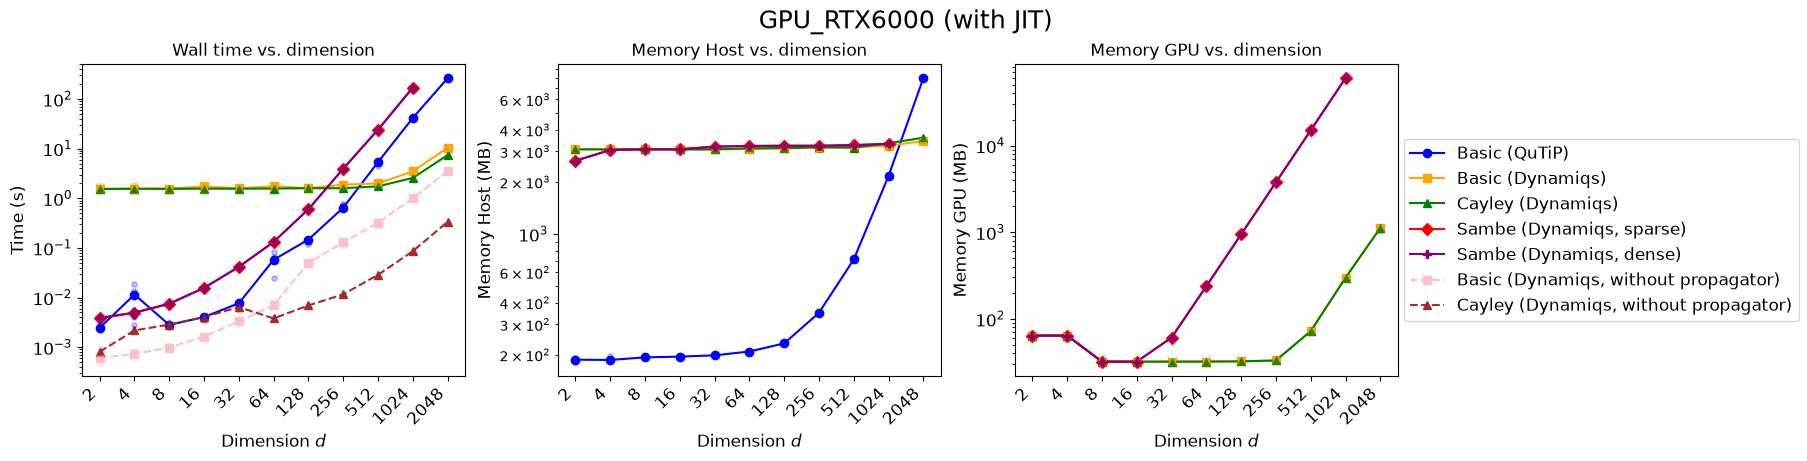

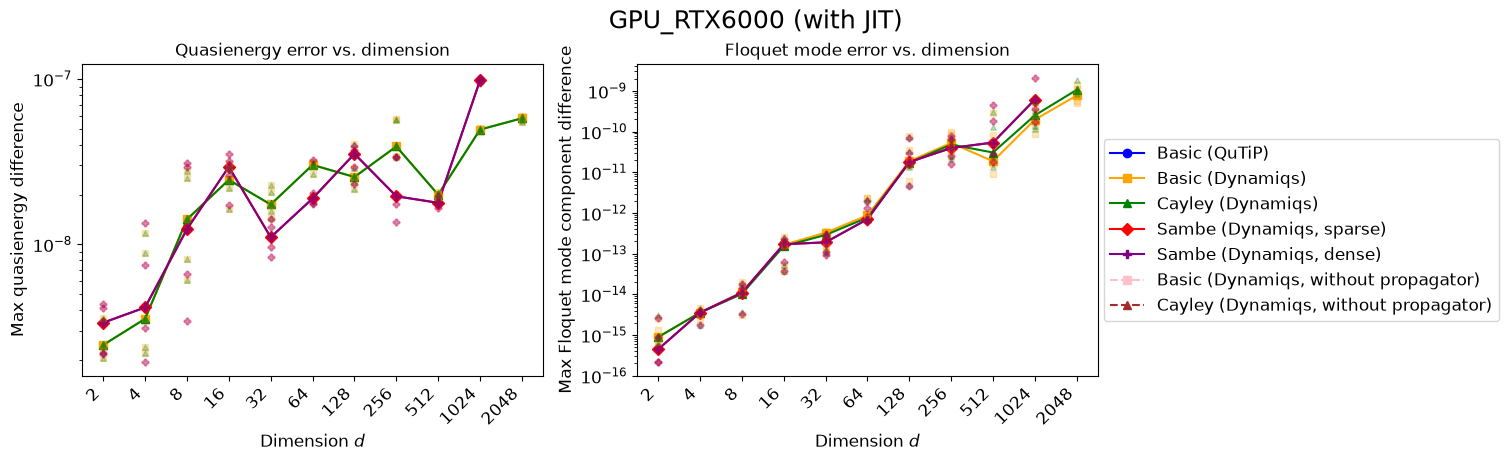

In [6]:
for device in devices:
    for jit in [False, True]:
        data = np.load(f'{out_dir}/{device}.npy', allow_pickle=True).item()
        plot_nonbasic(data, dims, basic_runs, jit=jit, 
                      suptitle=f'{device.upper()} ({"with" if jit else "without"} JIT)')